<a href="https://colab.research.google.com/github/erickdiaz3010/Economic-Complexity-Report/blob/Main-Branch-for-the-assigment/final_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import warnings
!pip install seaborn
import seaborn as sns
warnings.simplefilter(action='ignore', category=FutureWarning)


In [6]:
#Define Mcp, connecting (imaginary) countries and activities.

countries=['Vale of Arryn','The North','The Riverlands', 'Dorne', 'The Stormland','The Westerlands','The Reach']
activities=[f'P{j}' for j in range(9)]

Mcp=np.array([[1, 0, 1, 0, 1, 1, 0, 0, 1],
            [0, 1, 1, 0, 0, 1, 1, 0, 0],
            [0, 1, 0, 1, 1, 0, 0, 0, 0],
            [1, 0, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 1, 1, 0, 1],
            [0, 1, 1, 0, 1, 0, 1, 1, 1],
            [1, 1, 1, 1, 1, 0, 1, 1, 1]])
R,C=Mcp.shape

**1. Descriptive Statistics**

*   Provide key statistics on the countries, including measures of economic
diversification and specialization.
*   Analyze the ubiquity of products and activities.



🔹 Descriptive Statistics
Average diversification: 4.43
Median diversification: 4.00
Standard deviation of diversification: 1.92
Average ubiquity: 3.44
Median ubiquity: 4.00
Standard deviation of ubiquity: 0.96

Countries ordered by diversification: ['The Reach', 'The Westerlands', 'Vale of Arryn', 'The North', 'The Stormland', 'The Riverlands', 'Dorne']


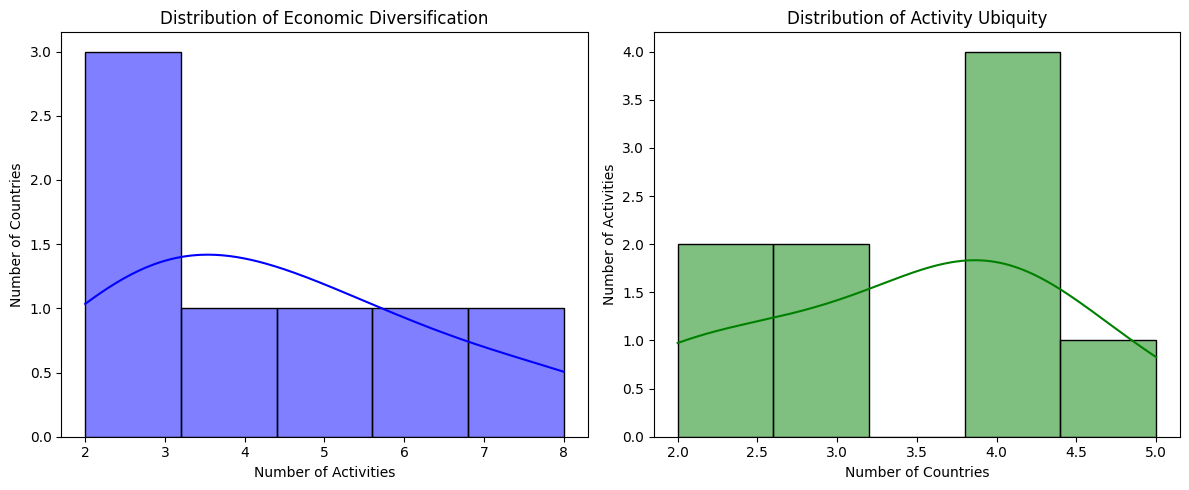

In [8]:

# Compute diversification (Number of activities per country)
diversification = Mcp.sum(axis=1)

# Compute ubiquity (Number of countries per activity)
ubiquity = Mcp.sum(axis=0)

# Order countries based on diversification
ordered_countries = np.argsort(diversification)[::-1]
sorted_countries = [countries[i] for i in ordered_countries]

# Print diversification and ubiquity statistics
print("🔹 Descriptive Statistics")
print(f"Average diversification: {np.mean(diversification):.2f}")
print(f"Median diversification: {np.median(diversification):.2f}")
print(f"Standard deviation of diversification: {np.std(diversification):.2f}")
print(f"Average ubiquity: {np.mean(ubiquity):.2f}")
print(f"Median ubiquity: {np.median(ubiquity):.2f}")
print(f"Standard deviation of ubiquity: {np.std(ubiquity):.2f}")
print("\nCountries ordered by diversification:", sorted_countries)

# Create histograms
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for diversification
sns.histplot(diversification, bins=5, kde=True, ax=ax[0], color='blue')
ax[0].set_title("Distribution of Economic Diversification")
ax[0].set_xlabel("Number of Activities")
ax[0].set_ylabel("Number of Countries")

# Histogram for ubiquity
sns.histplot(ubiquity, bins=5, kde=True, ax=ax[1], color='green')
ax[1].set_title("Distribution of Activity Ubiquity")
ax[1].set_xlabel("Number of Countries")
ax[1].set_ylabel("Number of Activities")

plt.tight_layout()
plt.show()

Descriptive Statistics Analysis
This section examines the economic diversification and specialization of the imaginary countries by analyzing their participation in various activities. Economic diversification measures the number of activities in which a country is involved, indicating whether its economy is broad-based or specialized. Activity ubiquity, on the other hand, quantifies how many countries engage in each activity, distinguishing between common and exclusive industries. To illustrate these metrics, two histograms display the distribution of diversification among countries and the ubiquity of activities across the dataset.

The results show that, on average, countries engage in 4.43 activities, with a median of 4.00 and a standard deviation of 1.92, highlighting variations in diversification levels. Meanwhile, activities are performed by an average of 3.44 countries, with a median of 4.00 and a standard deviation of 0.96, suggesting a relatively even distribution. The higher variability in diversification indicates that some countries are more specialized, while others engage in a broad range of activities, whereas the lower variability in ubiquity suggests that most activities are moderately widespread.

These findings provide insight into the economic structures of the countries, establishing a foundation for further analysis. Understanding how diversification and ubiquity interact is crucial for assessing economic complexity, which will be explored in the next section through Economic Complexity and Fitness Measures.

**2. Economic Complexity and Fitness Measures**

*   Compute and compare the Economic Complexity Index (ECI) and Fitness for
countries.
*   Calculate the Product Complexity Index (PCI) and Activity Complexity for
activities.

*   Discuss the differences between these methodologies and how they affect country rankings.





🔹 Fitness-Complexity Results
Vale of Arryn: Fitness = 0.7841
The North: Fitness = 0.6331
The Riverlands: Fitness = 0.9733
Dorne: Fitness = 0.2092
The Stormland: Fitness = 0.5130
The Westerlands: Fitness = 1.6189
The Reach: Fitness = 2.2684
P0: Complexity = 0.4434
P1: Complexity = 0.7858
P2: Complexity = 0.3313
P3: Complexity = 1.9616
P4: Complexity = 0.8569
P5: Complexity = 0.5996
P6: Complexity = 0.6279
P7: Complexity = 2.7210
P8: Complexity = 0.6725


<ipython-input-10-68557248bcb3>:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(countries))


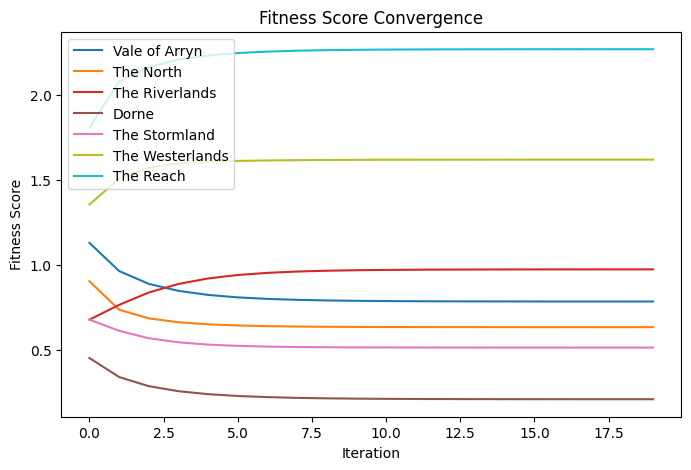

In [10]:
# Function to compute one iteration of the Fitness-Complexity Algorithm
def fitCompOneStep(Mcp, Fitness):
    R, C = Mcp.shape
    Complexity = np.zeros(C)

    for p in range(C):
        try:
            sumCT = Mcp[:, p] / Fitness
            sumCT[np.isnan(sumCT)] = 0.
            Complexity[p] = 1. / np.sum(sumCT)
            if np.isnan(Complexity[p]):
                Complexity[p] = 0
        except ZeroDivisionError:
            Complexity[p] = 0

    Fitness = np.dot(Mcp, Complexity)
    return Fitness / np.mean(Fitness), Complexity / np.mean(Complexity)

# Function to compute Fitness and Complexity over multiple iterations
def FitnessComplexity(Mcp, max_iterations=10):
    diversification = np.sum(Mcp, axis=1)
    ubiquity = np.sum(Mcp, axis=0)

    F = diversification / diversification.sum()
    Q = ubiquity / ubiquity.sum()

    for _ in range(max_iterations):
        F, Q = fitCompOneStep(Mcp, F)

    return (F / F.mean()), (Q / Q.mean())

# Compute Fitness and Complexity
fitness, complexity = FitnessComplexity(Mcp, max_iterations=20)

# Print results
print("🔹 Fitness-Complexity Results")
for i, country in enumerate(countries):
    print(f"{country}: Fitness = {fitness[i]:.4f}")

for j, activity in enumerate(activities):
    print(f"{activity}: Complexity = {complexity[j]:.4f}")

# Generate colors for each country
colors = plt.cm.get_cmap("tab10", len(countries))

# Plot Fitness convergence
iterations = 20
F_series = []

for it in range(iterations):
    F, _ = FitnessComplexity(Mcp, it)
    F_series.append(F)

F_series = np.array(F_series)

plt.figure(figsize=(8, 5))
for i, country in enumerate(countries):
    plt.plot(F_series[:, i], label=country, color=colors(i))

plt.xlabel("Iteration")
plt.ylabel("Fitness Score")
plt.title("Fitness Score Convergence")
plt.legend(loc="best")  # Add legend to identify countries
plt.show()

The Fitness-Complexity Algorithm (FCA) is an iterative approach used to evaluate the economic sophistication of countries and the relative complexity of activities. This method refines the relationship between diversification, which measures how many activities a country participates in, and ubiquity, which assesses how widespread an activity is across countries. By iteratively updating these values, the algorithm assigns rankings that distinguish between economies engaged in high-complexity sectors and those reliant on more basic activities. The results of this process stabilize over multiple iterations, as seen in the convergence graph, where the fitness scores of countries reach a steady state.

The analysis reveals clear disparities in economic sophistication among the countries studied. The Reach exhibits the highest fitness score (2.2684), indicating a highly diversified and complex economy. Similarly, The Westerlands (1.6189) also ranks among the most economically sophisticated regions, showing strong engagement in high-value activities. In contrast, The Riverlands (0.9733) and Vale of Arryn (0.7841) present moderate levels of economic development, participating in both common and complex activities. The North (0.6331) and The Stormland (0.5130) have lower fitness scores, suggesting a more limited scope of economic engagement. At the bottom, Dorne (0.2092) has the weakest economic structure, relying on a few, relatively simple industries.

The complexity scores for activities further illustrate the variation in economic participation. Activities such as P7 (2.7210) and P3 (1.9616) stand out as the most complex, as they are predominantly carried out by the most developed economies. Conversely, activities like P2 (0.3313) and P0 (0.4434) are the least complex, implying that they are widely accessible and can be performed even by less developed regions. Activities with moderate complexity, such as P1 (0.7858), P4 (0.8569), and P6 (0.6279), require a certain degree of economic sophistication but are not as exclusive as the most complex ones.

Overall, the fitness rankings suggest that The Reach and The Westerlands are the strongest economies, engaging in highly complex activities, while Dorne remains the most specialized and limited in its economic structure. The results also highlight that certain activities are exclusive to advanced economies, while others are broadly distributed among countries with varying levels of development. These findings set the stage for a comparative analysis between the Fitness-Complexity Algorithm and the Economic Complexity Index (ECI), which will provide further insights into how these two methodologies rank economic sophistication.

**3. Relatedness Between Activities**

*    Visualize and discuss the relatedness between economic activities.
*   Provide a graphical representation (e.g., network diagram or heatmap) illustrating the connections between different sectors.



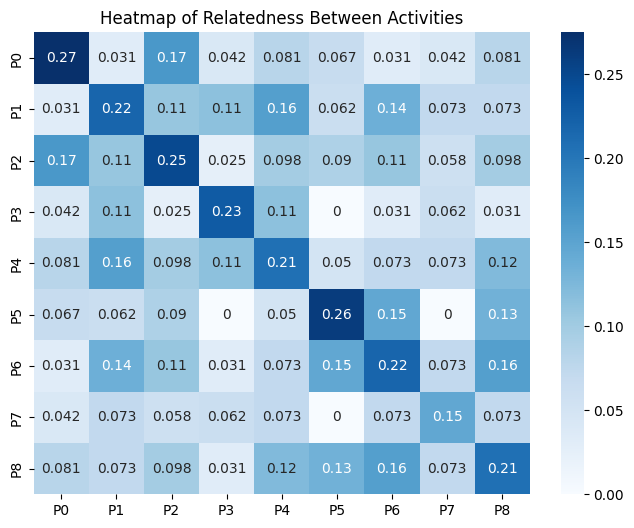

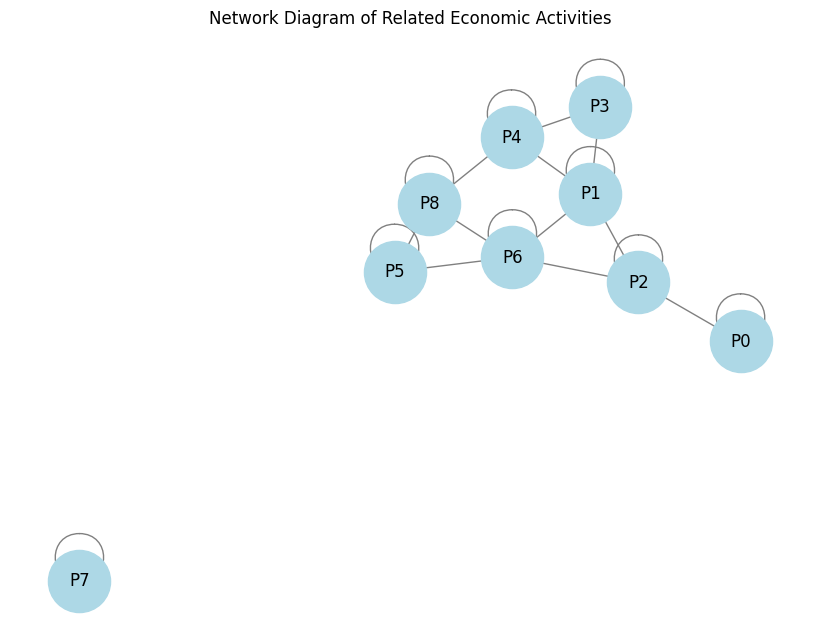

In [11]:
# Compute Co-occurrence Matrix (Jpp)
Jpp = Mcp.T @ Mcp  # Product-Product Matrix

# Compute Taxonomy Matrix (Adjusted Relatedness)
def Taxonomy(Mcp):
    diversification = Mcp.sum(axis=1)
    ubiquity = Mcp.sum(axis=0)

    Jpp = Mcp.T @ np.diag(1 / diversification) @ Mcp
    ubiMat = np.tile(ubiquity, (Mcp.shape[1], 1))
    ubiMax = np.maximum(ubiMat, ubiMat.T).astype(float)
    np.divide(np.ones_like(ubiMax, dtype=float), ubiMax, out=ubiMax, where=ubiMax != 0)

    return np.multiply(Jpp, ubiMax)

Bpp = Taxonomy(Mcp)  # Taxonomy Matrix

# Plot Heatmap of Relatedness
plt.figure(figsize=(8, 6))
sns.heatmap(Bpp, annot=True, cmap="Blues", xticklabels=activities, yticklabels=activities)
plt.title("Heatmap of Relatedness Between Activities")
plt.show()

# Network Visualization of Relatedness
threshold = 0.1  # Define cutoff for connections

G = nx.Graph()
G.add_nodes_from(activities)
edges = [(activities[i], activities[j]) for i in range(len(activities)) for j in range(len(activities)) if Bpp[i, j] > threshold]

G.add_edges_from(edges)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # Layout for network visualization
nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue", edge_color="gray", font_size=12)
plt.title("Network Diagram of Related Economic Activities")
plt.show()

The analysis of relatedness between economic activities provides a deeper understanding of how sectors interact within an economy. The heatmap of relatedness quantifies the strength of connections between different activities, where darker shades represent stronger co-occurrence. This indicates that certain activities tend to be developed together within the same countries, forming clusters of related industries. Notably, P0, P5, and P6 exhibit high levels of interconnection, suggesting that these activities frequently coexist within diversified economies. Conversely, activities with lower relatedness values are more isolated, meaning they are either highly specialized or not commonly found in combination with others.

The network diagram of economic activities further illustrates these relationships by mapping out the strongest connections between sectors. The structure of this network reveals a core cluster of interrelated activities, where activities P1, P2, P4, P5, P6, and P8 are densely connected, forming a cohesive group of industries that likely share common capabilities or production inputs. This suggests that countries engaged in one of these activities are well-positioned to expand into others within the same network. On the other hand, P7 remains isolated, indicating that it does not exhibit significant co-occurrence with other activities, potentially representing a highly specialized or niche sector.

From an economic complexity perspective, the presence of strong interconnections between activities suggests that countries can leverage their existing industries to transition into more complex and higher-value sectors. The structure of the network also aligns with the path-dependence theory of economic development, where countries tend to expand into industries that share production capabilities with their existing economic base. The observed clustering implies that countries seeking to enhance their economic complexity should focus on moving along the densely connected areas of the network, as these transitions are more feasible due to shared knowledge, infrastructure, and human capital requirements.

Overall, this analysis highlights the importance of relatedness in economic diversification strategies. Countries with a strong presence in interconnected industries can strategically develop adjacent industries to increase their economic complexity and global competitiveness. Meanwhile, highly specialized activities such as P7 may require targeted interventions to facilitate integration into the broader economic structure. This insight serves as a foundation for the next section, which will explore policy recommendations for economic diversification based on relatedness patterns.

**Diversification Strategies and Policy Recommendations**


The analysis of economic complexity and relatedness provides a structured framework for designing strategic diversification policies. By examining the fitness of each country and the relatedness between activities, we can identify optimal pathways for industrial expansion, leveraging existing economic structures to facilitate growth. The recommendations below are tailored to each country’s current economic position, focusing on feasible transitions into more complex and interconnected industries.

The Reach and The Westerlands, as the most sophisticated economies, should focus on deepening specialization in high-complexity industries while expanding into adjacent sectors with strong relatedness. Given their strong fitness scores and diversified economic bases, these countries can invest in high-value industries (e.g., P7 and P3), which remain underdeveloped in other regions. Policies should prioritize research and development (R&D), innovation ecosystems, and trade agreements that enhance integration into global value chains.

The Riverlands and Vale of Arryn, with moderate fitness scores, are well-positioned to expand into industries that are already well-connected within the existing economic structure. Their strategic approach should involve gradual diversification into moderately complex activities such as P4, P5, and P6, which exhibit strong network connections. Governments should implement industrial policies that support skill development, infrastructure investment, and incentives for firms to engage in these higher-value sectors, ensuring a smooth transition towards increased economic complexity.

The North and The Stormland, exhibiting lower fitness scores, should prioritize strengthening their industrial foundations by focusing on industries that serve as stepping stones toward complexity. These countries should target related activities in the economic network, such as P1 and P2, before attempting to move into more sophisticated industries. Policy measures should include education and workforce training programs, incentives for foreign direct investment (FDI), and technological upgrades to improve productivity and competitiveness.

Dorne, the least diversified economy, requires a fundamental shift in its industrial structure. Given its low fitness score and economic specialization, diversification should begin with the most accessible industries that are well-connected in the network. A structured development plan should emphasize infrastructure improvements, institutional support, and regional cooperation to create a conducive environment for industrial growth. Encouraging partnerships with more complex economies, such as The Reach and The Westerlands, could facilitate knowledge transfer and investment in higher-value sectors over time.

In conclusion, economic diversification should follow a path-dependent trajectory, leveraging relatedness between industries to ensure feasible and sustainable expansion. Countries with stronger economies should focus on advanced industrial upgrading, while less complex economies should develop strategic linkages to more established industries. By aligning industrial policies with economic complexity insights, governments can foster long-term growth, enhance competitiveness, and position their economies for future resilience in the global market.